# Retail Sales Forecasting using ARIMA & SARIMA
### A Time Series Forecasting Approach for Rossmann Stores

## Business Problem

Rossmann, one of Europe's largest pharmacy retail chains, operates thousands of stores across multiple regions. Accurate sales forecasting is essential for optimizing inventory levels, workforce planning, promotional strategies, and overall business operations. Poor forecasts can result in stock shortages, excess inventory, increased operational costs, and missed revenue opportunities.
The objective of this project is to analyze historical daily sales data from Rossmann stores, identify temporal patterns such as trends and seasonality, and develop statistical time series forecasting models capable of predicting future sales. Specifically, the project compares ARIMA and SARIMA models to determine which approach better captures the underlying sales patterns and provides more reliable forecasts.
Beyond model development, the project aims to translate statistical findings into actionable business insights that can support data-driven decision-making for retail operations.

## Project Objectives

The primary objective of this project is to forecast future daily sales for Rossmann stores using statistical time series forecasting techniques.

The project aims to:

- Understand historical sales patterns and seasonality.
- Analyze the impact of promotions and holidays on sales.
- Examine whether the sales series is stationary.
- Build ARIMA and SARIMA forecasting models.
- Compare forecasting performance using MAE, RMSE and MAPE.
- Generate business insights that can support inventory management, workforce planning and promotional strategies.

## Methodology

The project follows a structured data analytics workflow:

1. Data Collection
2. Data Cleaning and Preprocessing
3. Exploratory Data Analysis
4. Time Series Analysis
5. Stationarity Testing
6. Forecast Model Development
7. Model Evaluation
8. Business Insights and Recommendations

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option("display.max_columns", None)

# Better readability
pd.set_option("display.width", 120)

In [7]:
train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")

/var/folders/_t/npps8pqn09vfgv21k_fykjcw0000gn/T/ipykernel_8868/2005772569.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


In [8]:
print("Train Shape:", train.shape)
print("Store Shape:", store.shape)

Train Shape: (1017209, 9)
Store Shape: (1115, 10)


# Data Understanding - Lokking at the first few records helpes me in understanding variables before data preprocessing.

In [9]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [10]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


# info() provides dataset structure understanding, helps identify number of observations, data types and columns containing missing values. 

In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [12]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


# date column is still in float64 data type which needs to be changed to date-time format

# Statistical summary

In [13]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0


In [17]:
store.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1115.0,558.000000,322.017080,1.0,279.5,558.0,836.5,1115.0
CompetitionDistance,1112.0,5404.901079,7663.174720,20.0,717.5,2325.0,6882.5,75860.0
CompetitionOpenSinceMonth,761.0,7.224704,3.212348,1.0,4.0,8.0,10.0,12.0
CompetitionOpenSinceYear,761.0,2008.668857,6.195983,1900.0,2006.0,2010.0,2013.0,2015.0
Promo2,1115.0,0.512108,0.500078,0.0,0.0,1.0,1.0,1.0
Promo2SinceWeek,571.0,23.595447,14.141984,1.0,13.0,22.0,37.0,50.0
Promo2SinceYear,571.0,2011.763573,1.674935,2009.0,2011.0,2012.0,2013.0,2015.0


# Missing values analysis helps whether the missing values is important to the data or is it okay to have it, this helps to know whether imputation or removal is needed.

In [18]:
train.isnull().sum().sort_values(ascending=False)

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

In [19]:
store.isnull().sum().sort_values(ascending=False)

Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
CompetitionDistance            3
Store                          0
StoreType                      0
Assortment                     0
Promo2                         0
dtype: int64

# missing values in promo2 campaign represents that simply information is not applicable instead of errors in data collection

In [20]:
print("Train duplicates:", train.duplicated().sum())
print("Store duplicates:", store.duplicated().sum())

Train duplicates: 0
Store duplicates: 0


# Merge store and train data using common Store column so each daily sales record also contains information about corresponding store

In [15]:
df = train.merge(store, on="Store", how="left")

In [16]:
df.shape

(1017209, 18)

In [17]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [24]:
df.isnull().sum().sort_values(ascending=False)

PromoInterval                508031
Promo2SinceYear              508031
Promo2SinceWeek              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Sales                             0
Date                              0
StoreType                         0
dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [19]:
df["Date"] = pd.to_datetime(df["Date"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [29]:
print("Start Date :", df["Date"].min())
print("End Date   :", df["Date"].max())

Start Date : 2013-01-01 00:00:00
End Date   : 2015-07-31 00:00:00


# Exploring categorical variables and to identify any unexpected or inconsistent values present.

In [30]:
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


StateHoliday
StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64

StoreType
StoreType
a    551627
d    312912
c    136840
b     15830
Name: count, dtype: int64

Assortment
Assortment
a    537445
c    471470
b      8294
Name: count, dtype: int64

PromoInterval
PromoInterval
Jan,Apr,Jul,Oct     293122
Feb,May,Aug,Nov     118596
Mar,Jun,Sept,Dec     97460
Name: count, dtype: int64


In [31]:
df[df["StoreType"].isna()]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval


In [32]:
df["StoreType"].isna().sum()

np.int64(0)

In [33]:
print("Stores in train :", train["Store"].nunique())
print("Stores in store :", store["Store"].nunique())
print("Stores after merge :", df["Store"].nunique())

Stores in train : 1115
Stores in store : 1115
Stores after merge : 1115


# Checking whether the data is perefectly merged or missed during the process

In [34]:
merge_check = train.merge(
    store,
    on="Store",
    how="left",
    indicator=True
)

merge_check["_merge"].value_counts()

_merge
both          1017209
left_only           0
right_only          0
Name: count, dtype: int64

# Understanding the target variables

In [21]:
df["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

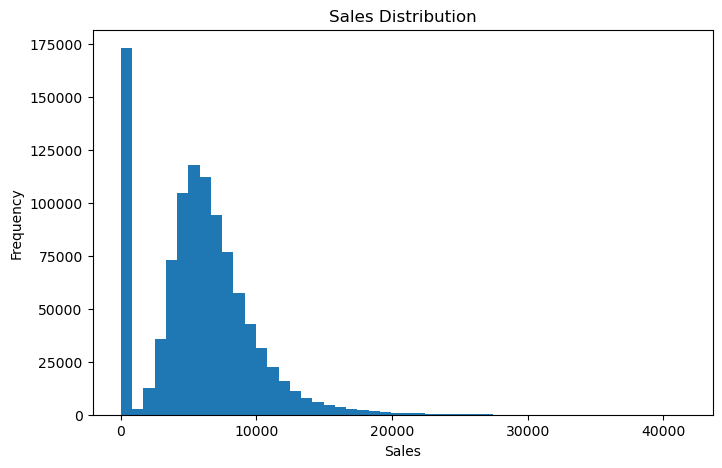

In [36]:
plt.figure(figsize=(8,5))
plt.hist(df["Sales"], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Noticeable concentration of zero sales observations which is likely when the stores are closed.

# Checking the skewness score of the sales graph to determine whether data is symmetric or not

In [37]:
df["Sales"].skew()

np.float64(0.6414596158103795)

In [38]:
print("Mean  :", df["Sales"].mean())
print("Median:", df["Sales"].median())


Mean  : 5773.818972305593
Median: 5744.0


In [39]:
df["Open"].value_counts(dropna=False)

Open
1    844392
0    172817
Name: count, dtype: int64

In [40]:
pd.crosstab(df["Open"], df["Sales"] == 0)

Sales,False,True
Open,,
0,0,172817
1,844338,54


# sales is 0 because the store is closed rather than due to poor business performance

investigating missing values

In [41]:
df.groupby("Promo2")[[
    "Promo2SinceWeek",
    "Promo2SinceYear",
    "PromoInterval"
]].apply(lambda x: x.isnull().sum())

,Promo2SinceWeek,Promo2SinceYear,PromoInterval
Promo2,,,
0,508031,508031,508031
1,0,0,0


# Store never participated in Promo2 due to which missing data is present

In [42]:
df.groupby(df["CompetitionDistance"].isna()).size()

CompetitionDistance
False    1014567
True        2642
dtype: int64

In [43]:
df[df["CompetitionDistance"].isna()][[
    "Store",
    "CompetitionDistance",
    "CompetitionOpenSinceYear",
    "CompetitionOpenSinceMonth"
]].head(15)

,Store,CompetitionDistance,CompetitionOpenSinceYear,CompetitionOpenSinceMonth
290,291,NaN,NaN,NaN
621,622,NaN,NaN,NaN
878,879,NaN,NaN,NaN
1405,291,NaN,NaN,NaN
1736,622,NaN,NaN,NaN
1993,879,NaN,NaN,NaN
2520,291,NaN,NaN,NaN
2851,622,NaN,NaN,NaN
3108,879,NaN,NaN,NaN
3635,291,NaN,NaN,NaN


In [44]:
# Open stores with zero sales
df[(df["Open"] == 1) & (df["Sales"] == 0)]

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
86825,971,5,2015-05-15,0,0,1,0,0,1,c,a,1140.0,5.0,2011.0,1,14.0,2012.0,"Mar,Jun,Sept,Dec"
142278,674,4,2015-03-26,0,0,1,0,0,0,a,a,2640.0,12.0,2005.0,1,31.0,2013.0,"Feb,May,Aug,Nov"
196938,699,4,2015-02-05,0,0,1,1,0,0,a,a,180.0,NaN,NaN,1,5.0,2013.0,"Jan,Apr,Jul,Oct"
322053,708,3,2014-10-01,0,0,1,1,0,0,c,c,11470.0,10.0,2009.0,1,18.0,2014.0,"Jan,Apr,Jul,Oct"
330176,357,1,2014-09-22,0,0,1,0,0,0,a,a,2060.0,10.0,2008.0,0,NaN,NaN,NaN
340348,227,4,2014-09-11,0,0,1,0,0,0,a,a,2370.0,NaN,NaN,0,NaN,NaN,NaN
340860,835,4,2014-09-11,0,0,1,0,0,0,a,a,2890.0,12.0,2007.0,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
341795,835,3,2014-09-10,0,0,1,0,0,0,a,a,2890.0,12.0,2007.0,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
346232,548,5,2014-09-05,0,0,1,1,0,1,d,c,3760.0,2.0,2009.0,0,NaN,NaN,NaN
346734,28,4,2014-09-04,0,0,1,1,0,0,a,a,1200.0,10.0,2014.0,1,6.0,2015.0,"Mar,Jun,Sept,Dec"


In [45]:
df = df[df["Open"] == 1].copy()

In [46]:
df.shape

(844392, 18)

# Since the objective is to forecast store sales during operational periods, records corresponding to closed stores were removed because zero sales resulted from store closure rather than customer demand.

In [47]:
(df["Sales"] == 0).sum()

np.int64(54)

In [48]:
df = df[df["Sales"] > 0].copy()

# Imputation of missing value with median. Distance is numeric and highly skewed.
# Median is more robust than mean.

In [49]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
    df["CompetitionDistance"].median()
)

In [22]:
df["CompetitionExists"] = np.where(
    df["CompetitionOpenSinceYear"].isna(),
    0,
    1
)

In [23]:
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].fillna(0)

In [24]:
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].fillna(0)

In [25]:
df["Promo2Exists"] = df["Promo2"]

In [26]:
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)
df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)
df["PromoInterval"] = df["PromoInterval"].fillna("None")

# StoreType, Assortment, StateHoliday and PromoInterval were converted to the category data type because they represent discrete categories rather than free text values. This reduces memory usage and prepares them for encoding during model development.

In [27]:
categorical_cols = [
    "StoreType",
    "Assortment",
    "StateHoliday",
    "PromoInterval"
]

for col in categorical_cols:
    df[col] = df[col].astype("category")

In [56]:
df.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
CompetitionExists            0
Promo2Exists                 0
dtype: int64

# Retail sales are influenced by calendar effects such as season, weekend, holidays, months etc therefore, multiple features were extracted from transaction date to capture these temporal patterns.

In [57]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["DayOfYear"] = df["Date"].dt.dayofyear

In [59]:
df["IsWeekend"] = (df["DayOfWeek"] >= 6).astype(int)

# Customer shopping behavior differs between weekdays and weekends.

In [60]:
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)

df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

# Many people recieve salary near month end or month start which affect consumer changing behavior.

In [61]:
df["CompetitionOpenSinceMonth"] = df["CompetitionOpenSinceMonth"].astype(int)
df["CompetitionOpenSinceYear"] = df["CompetitionOpenSinceYear"].astype(int)

In [62]:
competition_date = pd.to_datetime(
    dict(
        year=df["CompetitionOpenSinceYear"],
        month=df["CompetitionOpenSinceMonth"],
        day=1
    ),
    errors="coerce"
)

# This feature (competition age) captures how long a competing store has been operating at the time of each observation.

In [63]:
df["CompetitionAgeMonths"] = (
    (df["Date"] - competition_date).dt.days / 30
).clip(lower=0)

# 'SalesPerCustomer' is only used for EDA and business understanding. Since it directly depends on target variable used as an input feature during model training to avoid target leakage.

In [34]:
df["SalesPerCustomer"] = df["Sales"] / df["Customers"]

In [65]:
(df["Customers"] == 0).sum()

np.int64(0)

In [29]:
df["StateHoliday"] = df["StateHoliday"].replace("0", "None")

In [30]:
df["StateHoliday"].value_counts()

StateHoliday
None    855087
0       131072
a        20260
b         6690
c         4100
Name: count, dtype: int64

In [68]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompetitionExists,Promo2Exists,Year,Month,Day,Week,Quarter,DayOfYear,IsWeekend,IsMonthStart,IsMonthEnd,CompetitionAgeMonths,SalesPerCustomer
0,1,5,2015-07-31,5263,555,1,1,None,1,c,a,1270.0,9,2008,0,0.0,0.0,None,1,0,2015,7,31,31,3,212,0,0,1,84.133333,9.482883
1,2,5,2015-07-31,6064,625,1,1,None,1,a,a,570.0,11,2007,1,13.0,2010.0,"Jan,Apr,Jul,Oct",1,1,2015,7,31,31,3,212,0,0,1,94.300000,9.702400
2,3,5,2015-07-31,8314,821,1,1,None,1,a,a,14130.0,12,2006,1,14.0,2011.0,"Jan,Apr,Jul,Oct",1,1,2015,7,31,31,3,212,0,0,1,105.466667,10.126675
3,4,5,2015-07-31,13995,1498,1,1,None,1,c,c,620.0,9,2009,0,0.0,0.0,None,1,0,2015,7,31,31,3,212,0,0,1,71.966667,9.342457
4,5,5,2015-07-31,4822,559,1,1,None,1,a,a,29910.0,4,2015,0,0.0,0.0,None,1,0,2015,7,31,31,3,212,0,0,1,4.033333,8.626118


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 31 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      844338 non-null  int64         
 1   DayOfWeek                  844338 non-null  int64         
 2   Date                       844338 non-null  datetime64[ns]
 3   Sales                      844338 non-null  int64         
 4   Customers                  844338 non-null  int64         
 5   Open                       844338 non-null  int64         
 6   Promo                      844338 non-null  int64         
 7   StateHoliday               844338 non-null  category      
 8   SchoolHoliday              844338 non-null  int64         
 9   StoreType                  844338 non-null  category      
 10  Assortment                 844338 non-null  category      
 11  CompetitionDistance        844338 non-null  float64     

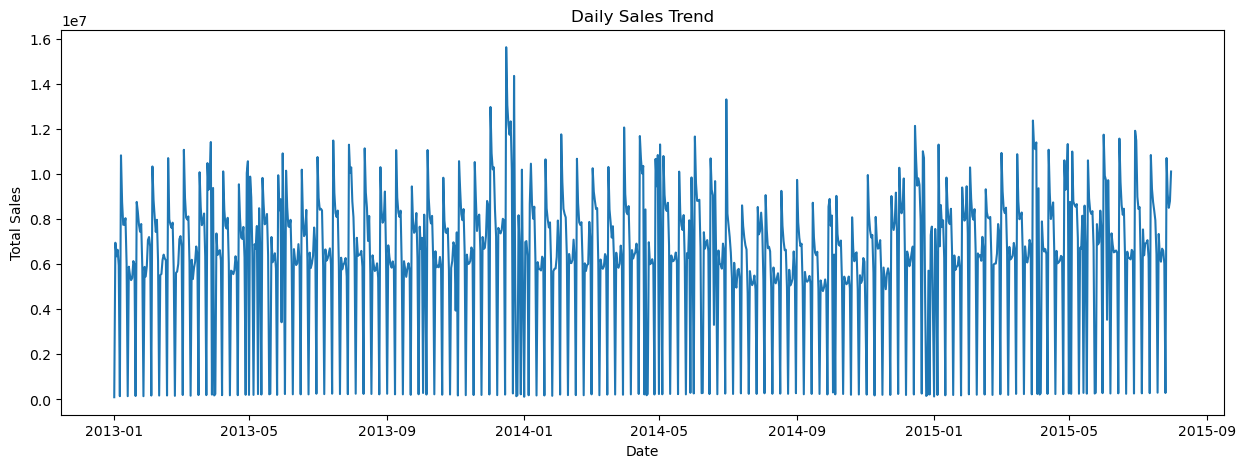

In [73]:
daily_sales = df.groupby("Date")["Sales"].sum().reset_index()

plt.figure(figsize=(15,5))
plt.plot(daily_sales["Date"], daily_sales["Sales"])
plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

# 1. Daily sales exhibit recurring fluctuations, indicating the presence of weekly and seasonal demand patterns, suggesting that time series forecasting methods capable of capturing seasonality may be appropriate.
# 2. Unusually high peaks are observed which likely corresponds to promotional campaign, holidays or festive shopping periods.

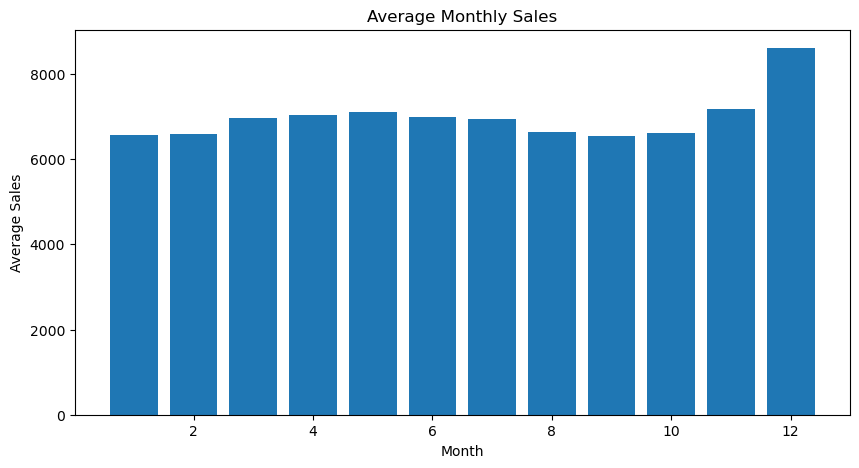

In [74]:
monthly_avg_sales = df.groupby("Month")["Sales"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.bar(monthly_avg_sales["Month"], monthly_avg_sales["Sales"])
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

# Insights
# 1. Monthly sales are maximum in december.
# 2. The spike in december reflects increased consumer spending during holiday season and year end shopping.

# Recommendation - Increase inventory, staffing and promotional planning before december to meet higher demand.

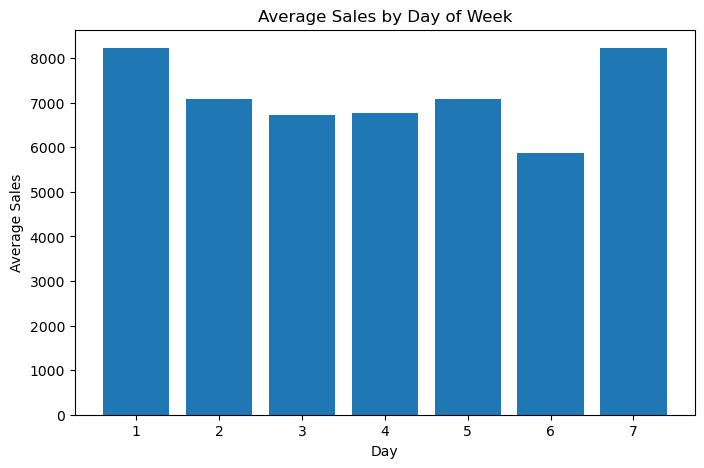

In [75]:
weekday_sales = df.groupby("DayOfWeek")["Sales"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.bar(weekday_sales["DayOfWeek"], weekday_sales["Sales"])
plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")
plt.show()

# 1. Monday and Sunday report high average sales.
# 2. sales continously decrease with days of the week before recovering towards the weekend.
# 3. Customer demand depends on day of the week. 

In [76]:
df.groupby("Promo")["Sales"].agg(["mean","median","count"])

,mean,median,count
Promo,,,
0,5929.826183,5459.0,467463
1,8228.739731,7650.0,376875


<Figure size 600x500 with 0 Axes>

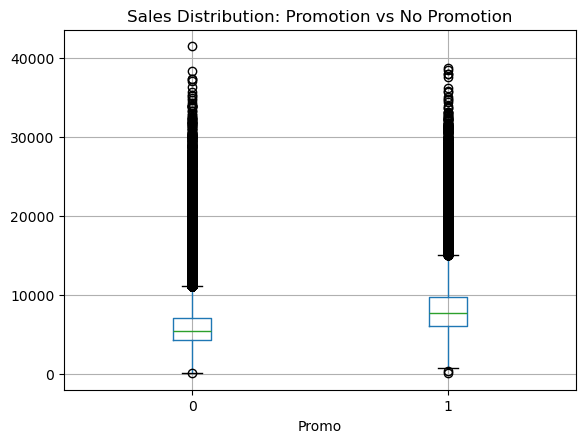

In [77]:
plt.figure(figsize=(6,5))
df.boxplot(column="Sales", by="Promo")
plt.title("Sales Distribution: Promotion vs No Promotion")
plt.suptitle("")
plt.show()

# Promotional campaigns attract considerably more customers as median customer footfall increases

In [31]:
df.groupby("Promo")["Customers"].agg(["mean", "median", "count"])

,mean,median,count
Promo,,,
0,517.823542,512.0,629129
1,820.098815,747.0,388080


<Figure size 600x500 with 0 Axes>

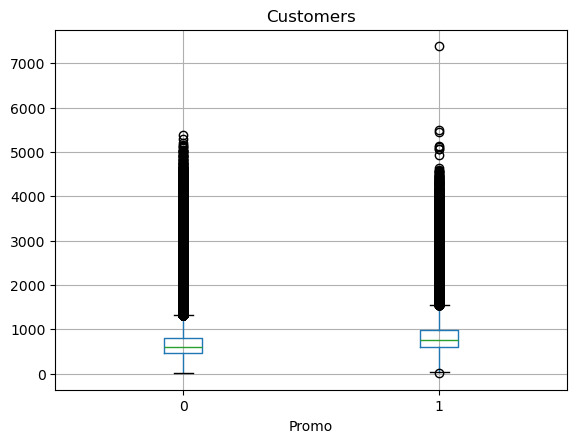

In [79]:
plt.figure(figsize=(6,5))
df.boxplot(column="Customers", by="Promo")
plt.suptitle("")
plt.show()

/var/folders/_t/npps8pqn09vfgv21k_fykjcw0000gn/T/ipykernel_58903/2535582790.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  store_sales = df.groupby("StoreType")["Sales"].mean().sort_values()


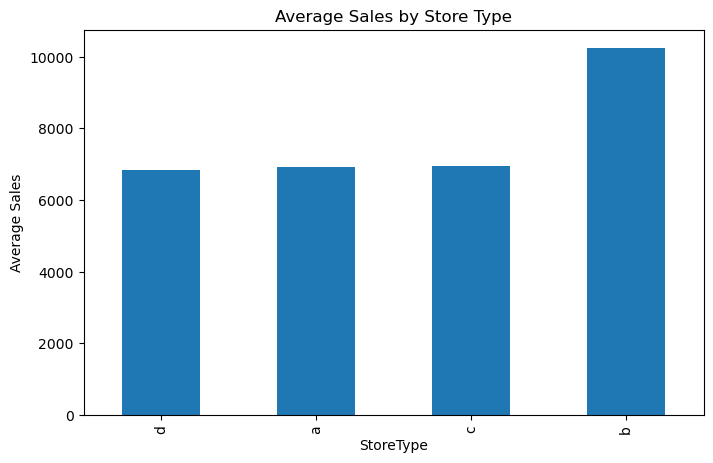

In [80]:
store_sales = df.groupby("StoreType")["Sales"].mean().sort_values()

store_sales.plot(kind="bar", figsize=(8,5))
plt.ylabel("Average Sales")
plt.title("Average Sales by Store Type")
plt.show()

# Store type b generates significantly higher average sales than all other store types.
# Store a,c,d exhibit similar performance.

# Insight - Store type appears to be a strong indicator of sales and can act as an important feature in forecasting model.

/var/folders/_t/npps8pqn09vfgv21k_fykjcw0000gn/T/ipykernel_58903/1086322727.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  assortment = df.groupby("Assortment")["Sales"].mean()


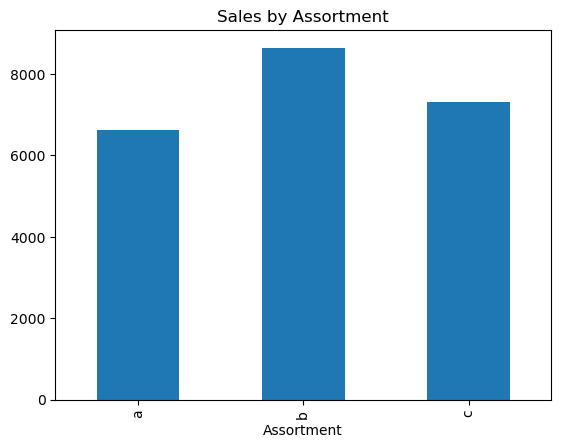

In [81]:
assortment = df.groupby("Assortment")["Sales"].mean()

assortment.plot(kind="bar")
plt.title("Sales by Assortment")
plt.show()

# Expanding product variety in lower performing stores may help increase customer spending.

In [35]:
df.groupby("StoreType")["SalesPerCustomer"].mean()

/var/folders/_t/npps8pqn09vfgv21k_fykjcw0000gn/T/ipykernel_8868/1219528448.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("StoreType")["SalesPerCustomer"].mean()


StoreType
a     8.846277
b     5.133097
c     8.626227
d    11.277862
Name: SalesPerCustomer, dtype: float64

/var/folders/_t/npps8pqn09vfgv21k_fykjcw0000gn/T/ipykernel_8868/1690368568.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("StoreType")["SalesPerCustomer"].mean().plot(kind="bar")


<Axes: xlabel='StoreType'>

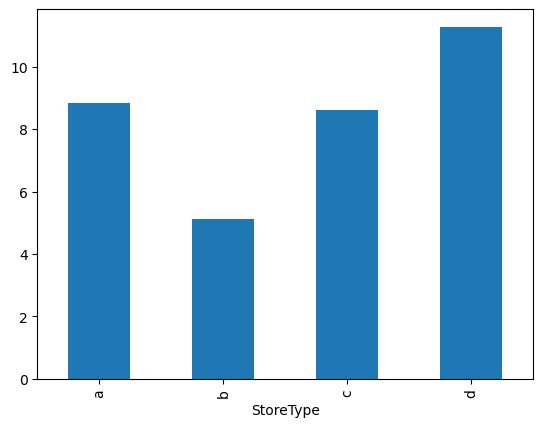

In [36]:
df.groupby("StoreType")["SalesPerCustomer"].mean().plot(kind="bar")

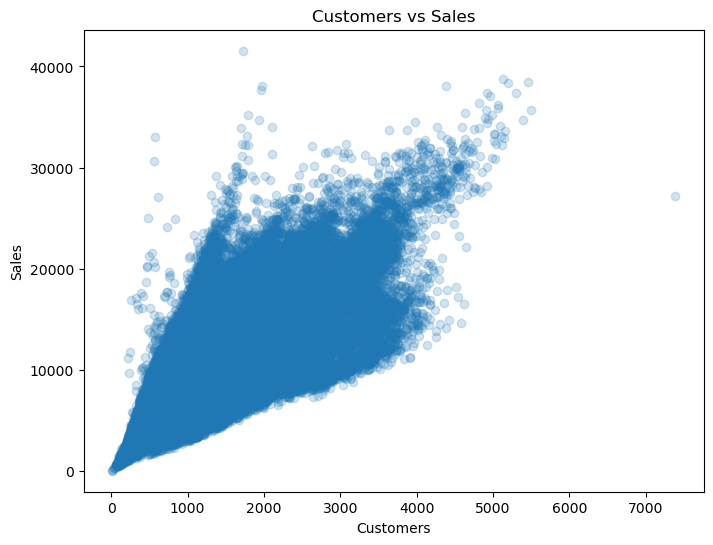

In [83]:
plt.figure(figsize=(8,6))
plt.scatter(df["Customers"], df["Sales"], alpha=0.2)
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Customers vs Sales")
plt.show()

### Observation

• Sales increase almost linearly with customer count.
• Customer traffic is one of the strongest drivers of store sales.
• Higher sales are primarily explained by increased footfall rather than unusually high spending per customer.

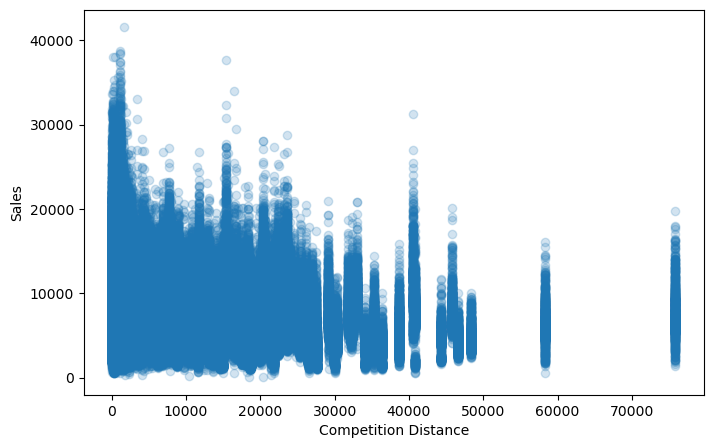

In [84]:
plt.figure(figsize=(8,5))
plt.scatter(
    df["CompetitionDistance"],
    df["Sales"],
    alpha=0.2
)
plt.xlabel("Competition Distance")
plt.ylabel("Sales")
plt.show()

### Observation

• Competition distance exhibits almost no linear relationship with sales.
• Correlation coefficient (-0.036) indicates only a negligible negative association.

### Interpretation

The influence of nearby competitors is likely more complex than simple physical distance and may depend on additional factors such as store type, promotions and location.

In [85]:
df[["CompetitionDistance","Sales"]].corr()

,CompetitionDistance,Sales
CompetitionDistance,1.000000,-0.035907
Sales,-0.035907,1.000000


/var/folders/_t/npps8pqn09vfgv21k_fykjcw0000gn/T/ipykernel_58903/3985300166.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  holiday_sales = df.groupby("StateHoliday")["Sales"].mean()


<Axes: xlabel='StateHoliday'>

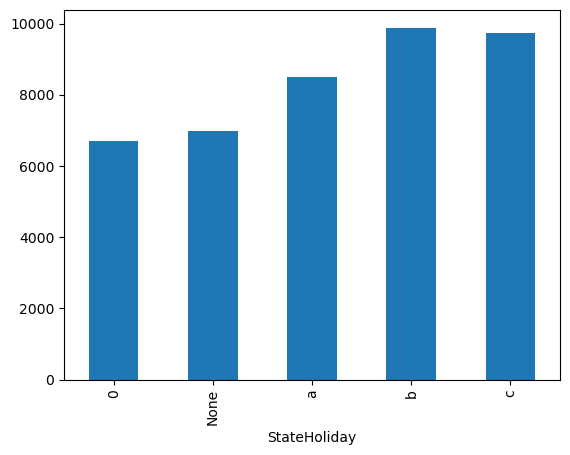

In [86]:
holiday_sales = df.groupby("StateHoliday")["Sales"].mean()

holiday_sales.plot(kind="bar")

### Observation

• Average sales appear higher during official state holidays.
• However, holiday categories contain substantially fewer observations than normal days.

### Interpretation

Additional statistical testing would be required before concluding that holidays consistently increase sales.

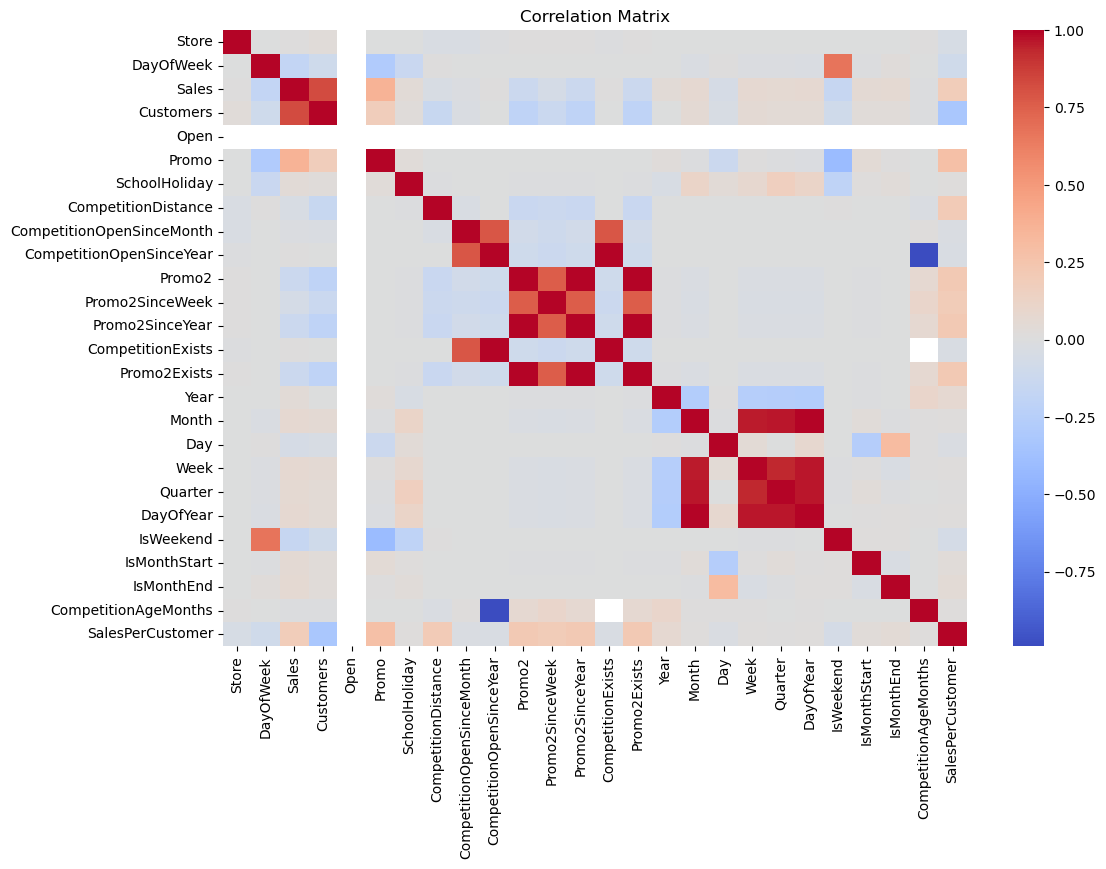

In [87]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)
plt.title("Correlation Matrix")
plt.show()

### Correlation Matrix

• Sales exhibits the strongest positive correlation with Customers.
• Promo also shows a positive relationship with Sales.
• CompetitionDistance has negligible correlation with Sales.
• Calendar-derived features such as Month, Week and Quarter are naturally correlated with one another because they originate from the Date variable.
• Engineered features demonstrate meaningful relationships, indicating successful feature engineering.

## Time Series Analysis

In [52]:
ts = df.groupby("Date")["Sales"].sum().sort_index()

ts.head()

Date
2013-01-01      97235
2013-01-02    6949829
2013-01-03    6347820
2013-01-04    6638954
2013-01-05    5951593
Name: Sales, dtype: int64

In [89]:
ts.shape

(942,)

In [51]:
ts.tail()

Date
2015-07-27    10707292
2015-07-28     9115073
2015-07-29     8499962
2015-07-30     8798854
2015-07-31    10109742
Name: Sales, dtype: int64

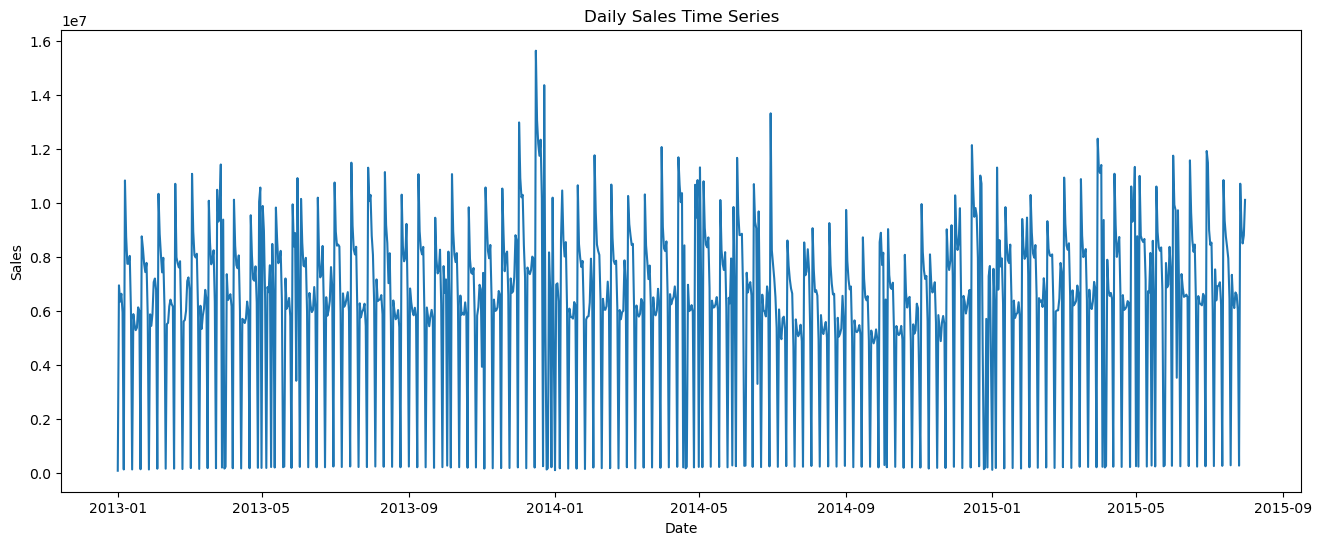

In [91]:
plt.figure(figsize=(16,6))

plt.plot(ts)

plt.title("Daily Sales Time Series")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

### Observation

• Daily sales exhibit clear recurring weekly and seasonal fluctuations.
• Several prominent spikes indicate periods of unusually high demand, likely associated with promotions or holidays.
• The series does not appear completely stationary because both the average level and variability change over time.

In [92]:
rolling_mean = ts.rolling(window=30).mean()

rolling_std = ts.rolling(window=30).std()

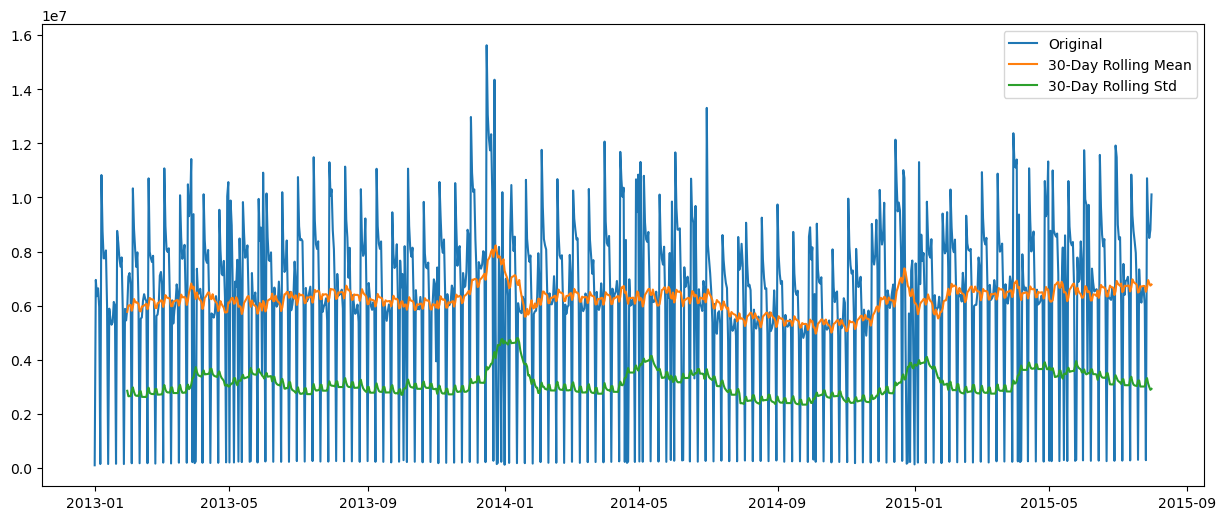

In [93]:
plt.figure(figsize=(15,6))

plt.plot(ts, label="Original")

plt.plot(rolling_mean, label="30-Day Rolling Mean")

plt.plot(rolling_std, label="30-Day Rolling Std")

plt.legend()

plt.show()

### Observation

• Both the rolling mean and rolling standard deviation vary throughout the observation period.
• The changing average level and variance indicate that the sales series is non-stationary.

### Implication

The forecasting model should account for trend and seasonality rather than assuming constant statistical properties over time.

In [94]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [95]:
import statsmodels
print(statsmodels.__version__)

0.14.6


In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [44]:
decomposition = seasonal_decompose(
    ts,
    model="additive",
    period=7
)

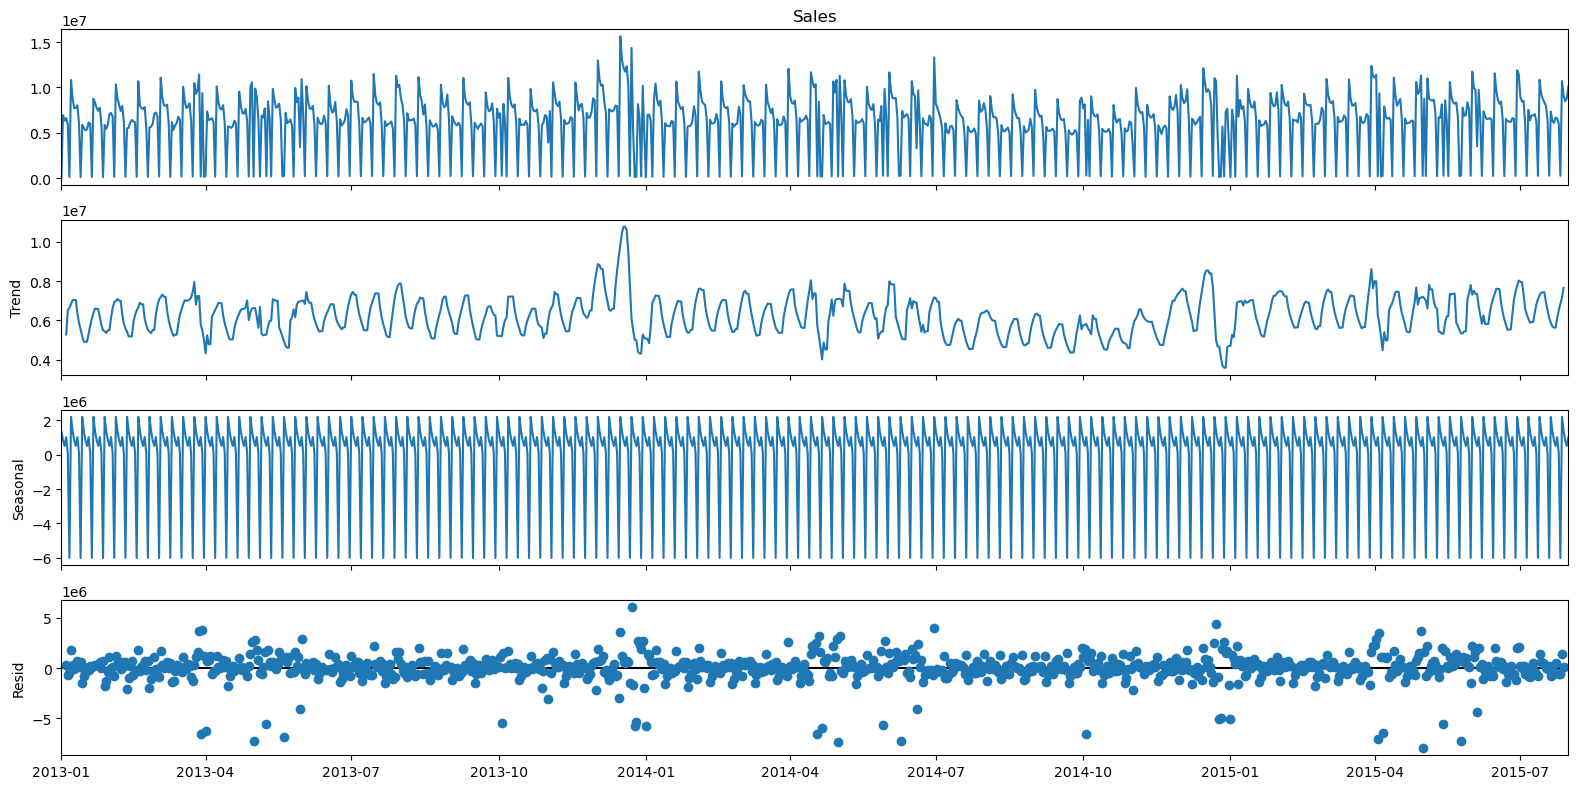

In [47]:
plt.rcParams["figure.figsize"] = (16, 8)

decomposition.plot()
plt.show()

### Observations

- Sales show a clear weekly seasonal pattern.
- The overall trend declines during mid-2014 before recovering towards the end.
- Most of the remaining variation is captured after removing trend and seasonality.
- A few large residual spikes are still present, likely due to promotions or holidays.

### Business Insight

Weekly demand has a strong influence on sales, so forecasting models should include weekly seasonality.

In [53]:
monthly_sales = (
    daily_sales
    .resample("M")
    .sum()
)

/var/folders/_t/npps8pqn09vfgv21k_fykjcw0000gn/T/ipykernel_8868/2700879070.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


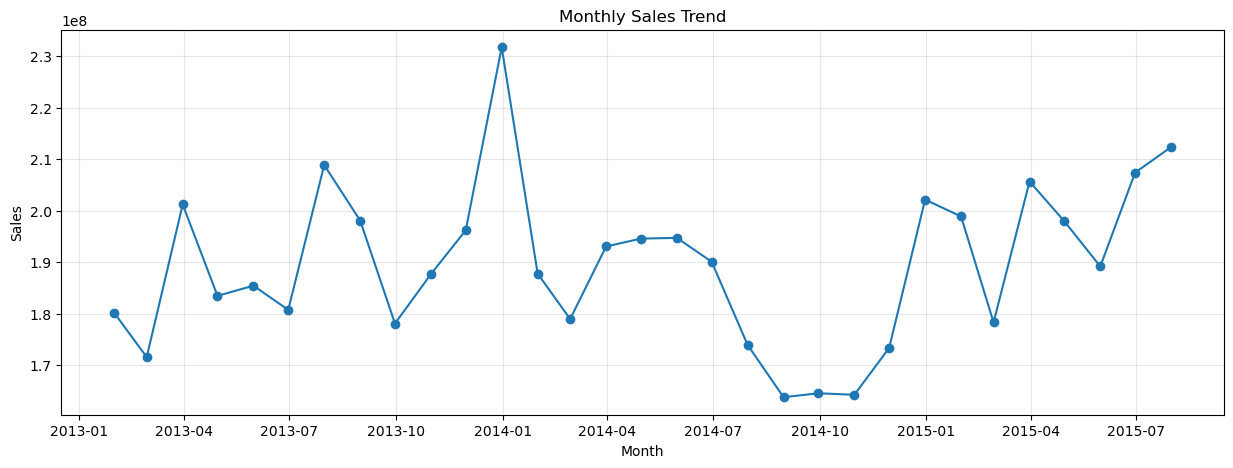

In [54]:
plt.figure(figsize=(15,5))
plt.plot(monthly_sales, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(alpha=0.3)
plt.show()

### Observation

Monthly sales fluctuate throughout the period. Sales peak around December 2013, decline during late 2014, and recover steadily in 2015. This suggests seasonal effects rather than a long term decline.

## Augmented Dickey Fuller Test

In [99]:
from statsmodels.tsa.stattools import adfuller

In [100]:
result = adfuller(ts)

In [101]:
print("ADF Statistic:", result[0])

print("p-value:", result[1])

ADF Statistic: -4.761614524595612
p-value: 6.436731330559378e-05


## First-Order Differencing

The original sales series showed signs of non-stationarity. First-order differencing was applied to remove the trend and stabilize the series before building the forecasting models.

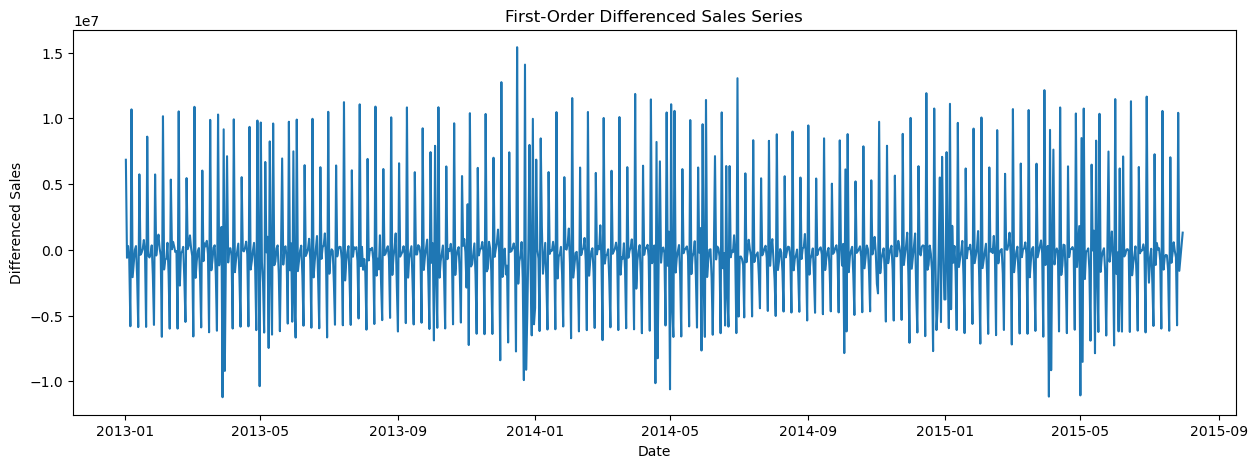

In [67]:
ts_diff = ts.diff().dropna()

plt.figure(figsize=(15,5))
plt.plot(ts_diff)

plt.title("First-Order Differenced Sales Series")
plt.xlabel("Date")
plt.ylabel("Differenced Sales")

plt.show()

In [103]:
result = adfuller(ts_diff)

print(result[1])

3.750044004604795e-26


### Observation

The Augmented Dickey-Fuller test gives a p-value well below 0.05, indicating that the daily sales series is already stationary. Although first-order differencing further reduces the p-value, the original series is suitable for most time series analyses.

## ACF and PACF Analysis

After making the series stationary, I used the ACF and PACF plots to understand the autocorrelation structure of the data. These plots provide a starting point for selecting suitable values of p and q for the ARIMA model.

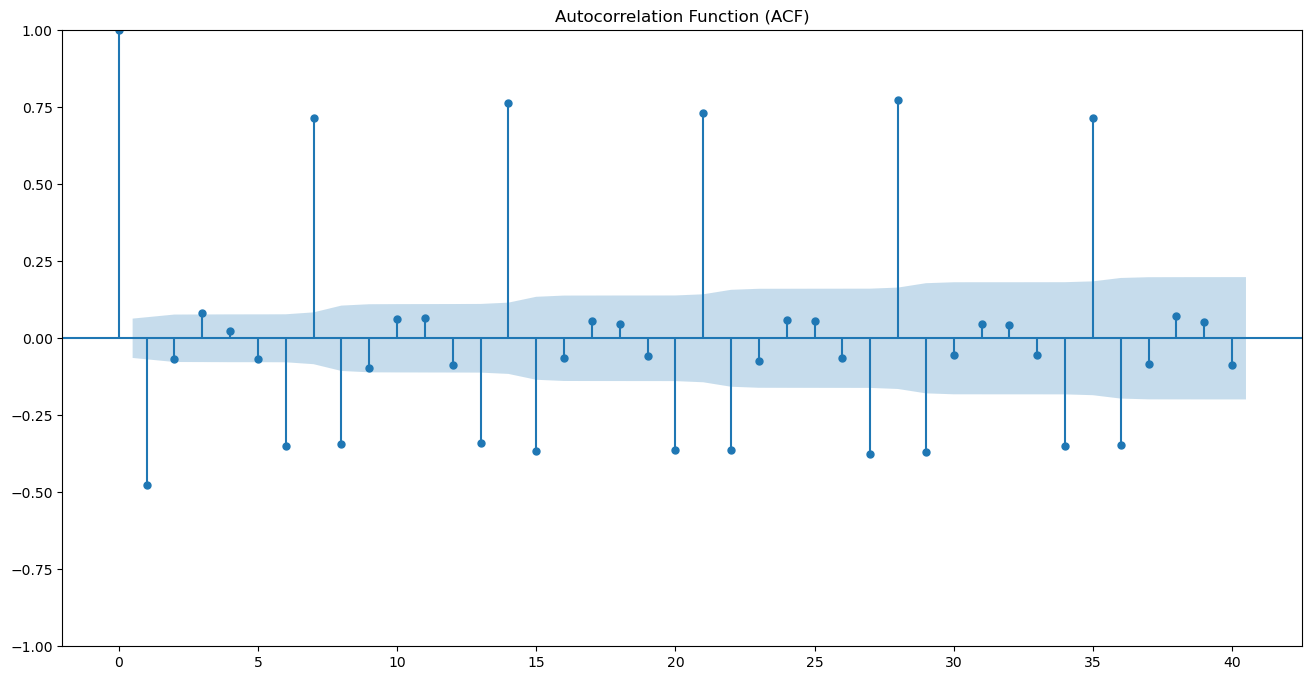

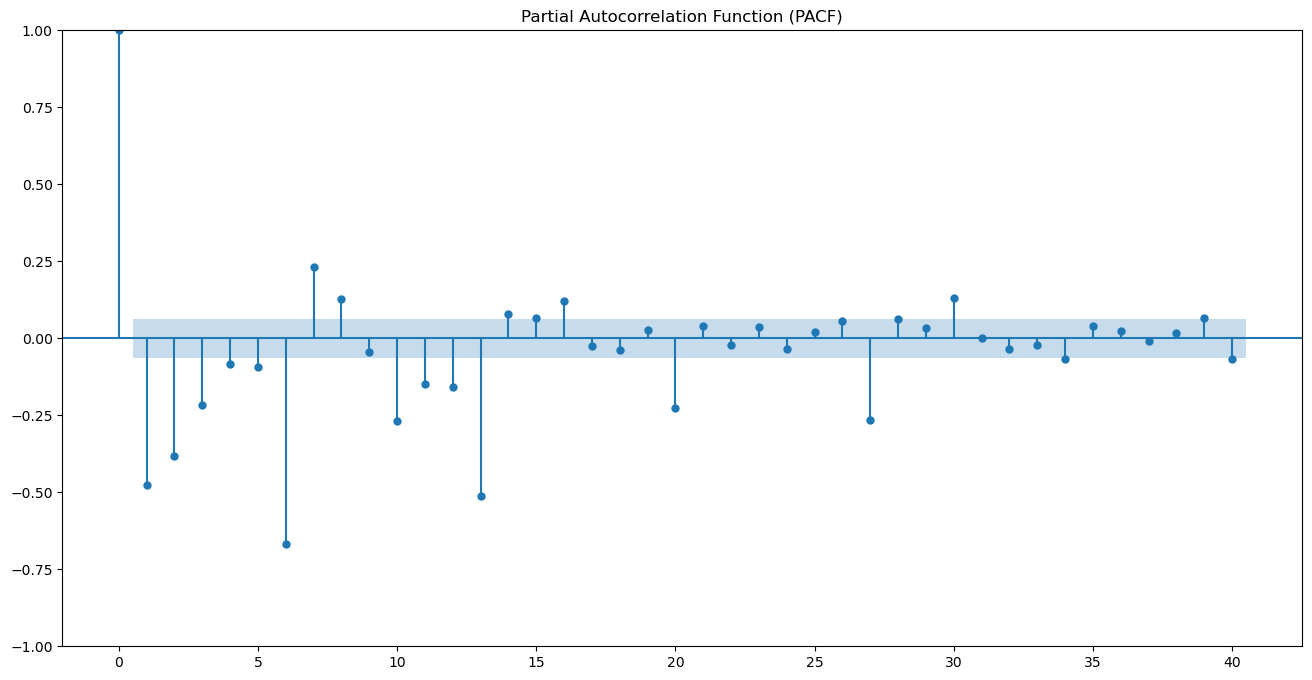

In [69]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts_diff, lags=40)
plt.title("Autocorrelation Function (ACF)")
plt.show()

plot_pacf(ts_diff, lags=40, method="ywm")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

### Observation

The ACF plot shows significant autocorrelation at multiples of 7 (7, 14, 21, ...), indicating a strong weekly seasonal pattern in the sales data. The PACF also contains several significant lags before gradually tapering off, suggesting that both autoregressive and moving average components may be useful.

Based on these plots, ARIMA(1,1,1) was selected as a reasonable starting model, while the seasonal pattern motivated the use of a SARIMA model with a seasonal period of 7 days.

## Train Test Split

In [56]:
train_size = int(len(daily_sales) * 0.8)

train = daily_sales[:train_size]

test = daily_sales[train_size:]

print(train.shape)
print(test.shape)

(753,)
(189,)


# Since forecasting relies on chronological order, the dataset was split sequentially without shuffling. The first 80% of observations were used for training and the remaining 20% for evaluation.

## Baseline Model

In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [59]:
naive_forecast = test.shift(1)

naive_forecast = naive_forecast.dropna()
baseline_actual = test.iloc[1:]

baseline_mae = mean_absolute_error(baseline_actual, naive_forecast)
baseline_rmse = np.sqrt(mean_squared_error(baseline_actual, naive_forecast))
baseline_mape = mean_absolute_percentage_error(baseline_actual, naive_forecast)

print("MAE :", baseline_mae)
print("RMSE :", baseline_rmse)
print("MAPE :", baseline_mape)

MAE : 3064949.462765957
RMSE : 4704536.842703778
MAPE : 4.75313718361928


## Baseline Model

A simple naive forecast was used as the baseline, where the previous day's sales are used as the prediction for the next day. This provides a benchmark for evaluating the forecasting models.

## Build ARIMA

In [60]:
p = 1
d = 1
q = 1

from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(p, d, q))
model_fit = model.fit()

arima_forecast = model_fit.forecast(steps=len(test))

/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Build ARIMA

An ARIMA(1,1,1) model was trained to capture the trend and short-term dependencies in the sales data.

In [61]:
arima_mae = mean_absolute_error(test, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
arima_mape = mean_absolute_percentage_error(test, arima_forecast)

print("MAE :", arima_mae)
print("RMSE :", arima_rmse)
print("MAPE :", arima_mape)

MAE : 2591846.107843467
RMSE : 3288908.231385369
MAPE : 4.150522305789899


### Observation

The ARIMA model captures the overall sales trend but struggles to model the recurring weekly fluctuations.

In [116]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(p,d,q))
model_fit = model.fit()

/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [117]:
model_fit = model.fit()

In [130]:
arima_forecast = model_fit.forecast(steps=len(test))

## Build SARIMA

In [62]:
P = 1
D = 1
Q = 1
s = 7

from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima = SARIMAX(
    train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, s)
)

sarima_fit = sarima.fit()

sarima_forecast = sarima_fit.forecast(steps=len(test))

/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/anshikapandey/miniconda3/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


## Build SARIMA

A seasonal ARIMA model was trained to account for the weekly seasonality observed during exploratory analysis.

In [63]:
sarima_mae = mean_absolute_error(test, sarima_forecast)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_forecast))
sarima_mape = mean_absolute_percentage_error(test, sarima_forecast)

print("MAE :", sarima_mae)
print("RMSE :", sarima_rmse)
print("MAPE :", sarima_mape)

MAE : 1315796.3210186933
RMSE : 1920422.2513396707
MAPE : 1.0110397183284436


### Observation

Including seasonal components improves the model's ability to capture weekly sales patterns.

In [64]:
comparison = pd.DataFrame({
    "Model": ["ARIMA", "SARIMA"],
    "MAE": [arima_mae, sarima_mae],
    "RMSE": [arima_rmse, sarima_rmse],
    "MAPE": [arima_mape, sarima_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,ARIMA,2.591846e+06,3.288908e+06,4.150522
1,SARIMA,1.315796e+06,1.920422e+06,1.011040


## Model Comparison

The forecasting models were compared using MAE, RMSE and MAPE. Lower values indicate better predictive performance.

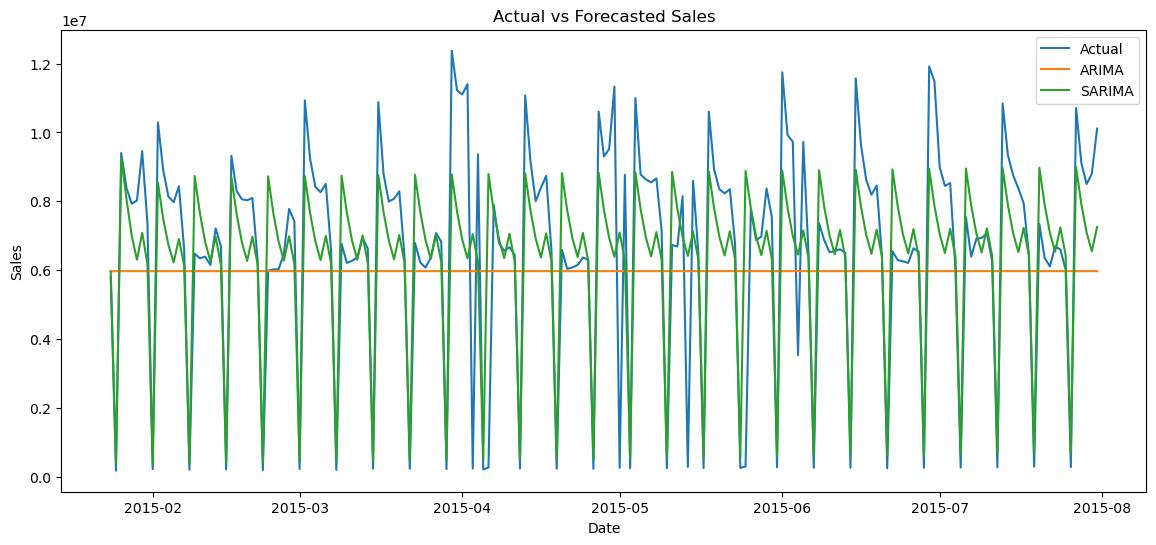

In [65]:
plt.figure(figsize=(14,6))

plt.plot(test.index, test, label="Actual")

plt.plot(test.index, arima_forecast, label="ARIMA")

plt.plot(test.index, sarima_forecast, label="SARIMA")

plt.legend()

plt.title("Actual vs Forecasted Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.show()

### Observation

The SARIMA model follows the weekly sales pattern more closely, while ARIMA produces smoother forecasts and misses much of the seasonal variation.

In [70]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "ARIMA", "SARIMA"],
    "MAE": [baseline_mae, arima_mae, sarima_mae],
    "RMSE": [baseline_rmse, arima_rmse, sarima_rmse],
    "MAPE": [baseline_mape, arima_mape, sarima_mape]
})

comparison

,Model,MAE,RMSE,MAPE
0,Baseline,3.064949e+06,4.704537e+06,4.753137
1,ARIMA,2.591846e+06,3.288908e+06,4.150522
2,SARIMA,1.315796e+06,1.920422e+06,1.011040


### Observation

Among the three models, SARIMA achieved the lowest forecasting error. This indicates that incorporating weekly seasonality improved the forecasting performance compared to both the baseline and the standard ARIMA model.

## Residual Diagnostics

The residuals of the final SARIMA model were analysed to check whether the remaining errors behaved like random noise. Ideally, the residuals should fluctuate randomly around zero without any clear trend or pattern.

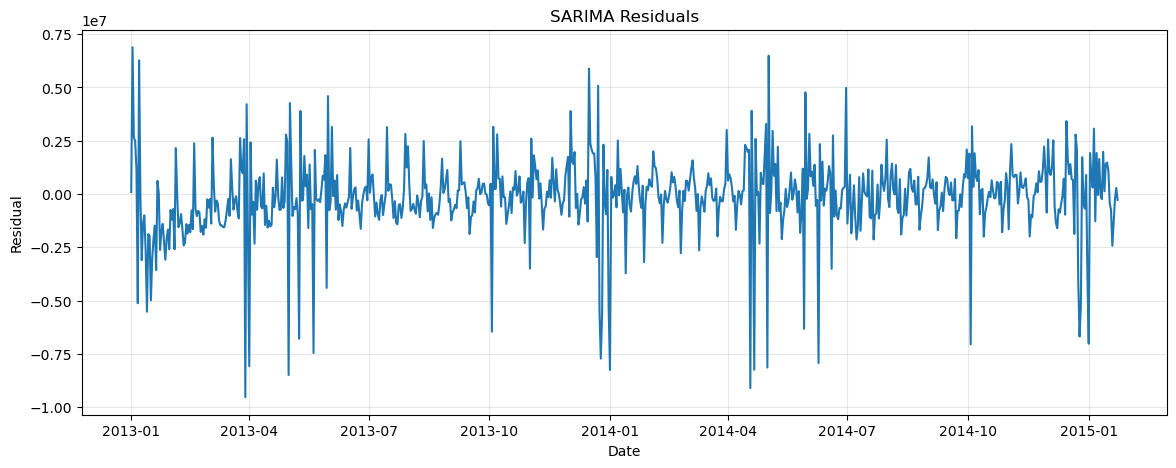

In [71]:
residuals = sarima_fit.resid

plt.figure(figsize=(14,5))
plt.plot(residuals)

plt.title("SARIMA Residuals")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.grid(alpha=0.3)
plt.show()

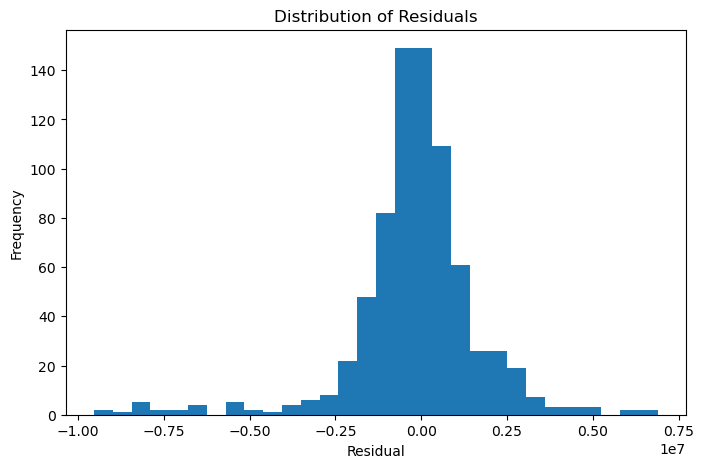

In [72]:
plt.figure(figsize=(8,5))

plt.hist(residuals, bins=30)

plt.title("Distribution of Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

## Future Sales Forecast

The trained SARIMA model was used to forecast sales for the next 30 days beyond the available dataset. This demonstrates how the model can be used for future planning.

In [73]:
future_forecast = sarima_fit.forecast(steps=30)

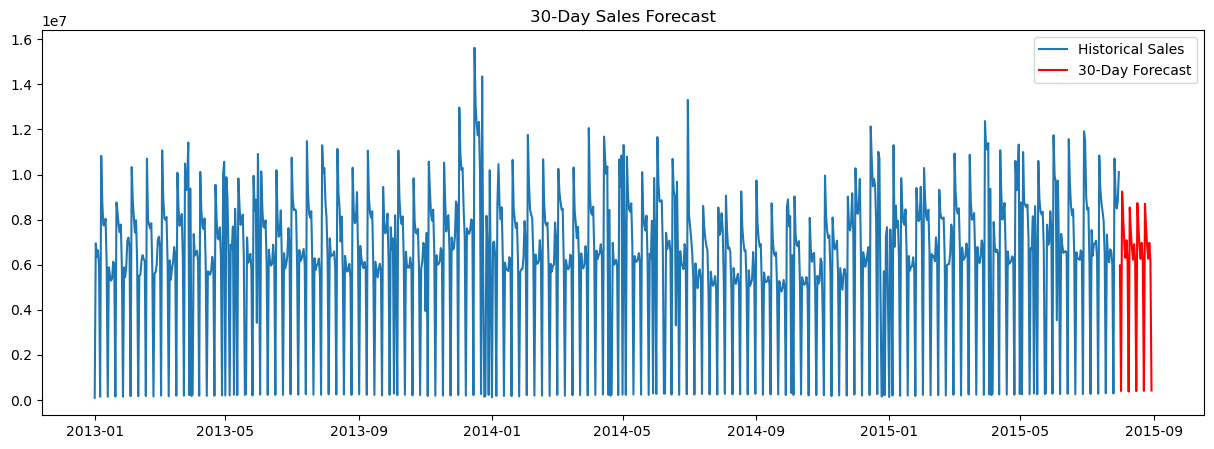

In [74]:
plt.figure(figsize=(15,5))

plt.plot(daily_sales, label="Historical Sales")

future_dates = pd.date_range(
    start=daily_sales.index[-1] + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

plt.plot(future_dates,
         future_forecast,
         color="red",
         label="30-Day Forecast")

plt.legend()

plt.title("30-Day Sales Forecast")

plt.show()

### Observation

The forecast follows the weekly seasonal pattern observed in the historical data, indicating that the model has successfully learned recurring sales behaviour.

# Final Conclusion

This project analysed Rossmann daily sales using time series forecasting techniques.

Key findings:

- Daily sales exhibit a strong weekly seasonal pattern.
- First-order differencing was sufficient to achieve stationarity.
- The ACF and PACF plots supported the use of ARIMA-based models.
- SARIMA outperformed both the baseline and ARIMA models by capturing weekly seasonality.
- The trained SARIMA model was also used to generate future sales forecasts, demonstrating its usefulness for inventory planning and operational decision-making.